#### This dataset captures detailed information on building energy consumption, outdoor temperature, and occupancy levels, recorded at 15-minute intervals. The data spans from May 22, 2018, to December 31, 2018.

In [37]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [38]:
df = pd.read_excel("C:/Users/PC/Desktop/Data Sets/ziad/cleandata.xlsx",usecols=['Power Consumption','Outdoor Temperature'],nrows=500)
print(df)
x = df[['Outdoor Temperature']]
y = df['Power Consumption']

     Power Consumption  Outdoor Temperature
0                71.98                15.72
1                71.00                15.37
2                65.20                15.27
3                95.90                16.03
4                43.60                15.28
..                 ...                  ...
495              56.20                13.53
496              58.30                13.32
497              61.60                13.09
498              61.60                12.86
499              53.45                12.59

[500 rows x 2 columns]


In [39]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.3,random_state=42)

model = LinearRegression()
model.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[-0.81]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['Outdoor Temperature']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,77.43
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,1


In [40]:
y_pred = model.predict(x_test)

In [41]:
from sklearn.metrics import mean_absolute_error
print(f"MAE: {mean_absolute_error(y_test,y_pred)}")

MAE: 18.154465122465115


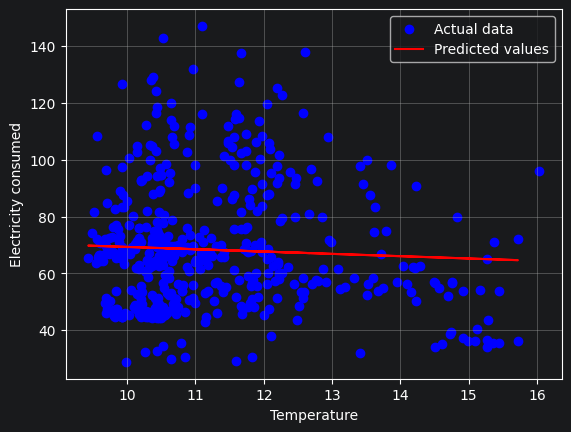

In [42]:
plt.scatter(x,y,label="Actual data",color="blue")
plt.plot(x_test,y_pred,label="Predicted values",color="red")
plt.xlabel("Temperature")
plt.ylabel("Electricity consumed")
plt.legend()
plt.grid(True)
plt.show()